# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

In [ ]:
#answers to 1-4 are on the github repo 

**Declaration:** I completed this version without generative AI.

**Student(s):** Cody Chhea 

**Date:** 9/11/2026

Text(0, 0.5, 'Count')

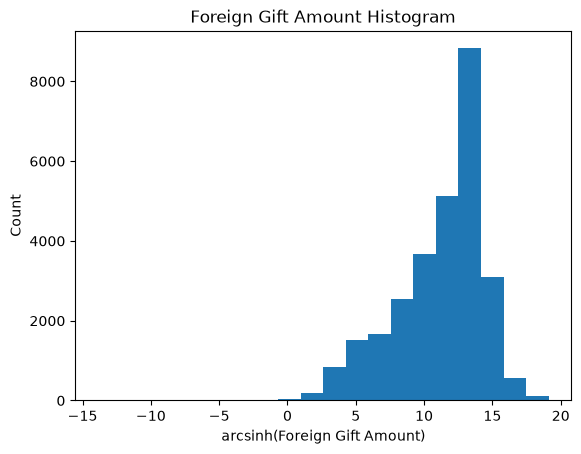

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#unsure about titles of x and y 
df = pd.read_csv('ForeignGifts_edu.csv')
df["gifts_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
df["gifts_arcsinh"].hist(bins=20, grid=False)
plt.xlabel("gifts_arcsinh")
plt.title("Foreign Gift Amount Histogram")
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Count")




The Foreign Gift Amount histogram reveals that this histogram is not a good representation. Some values are too high (millions) while others are little, causing the x-axis to be too big to really observe anything of value. 

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: count, dtype: float64

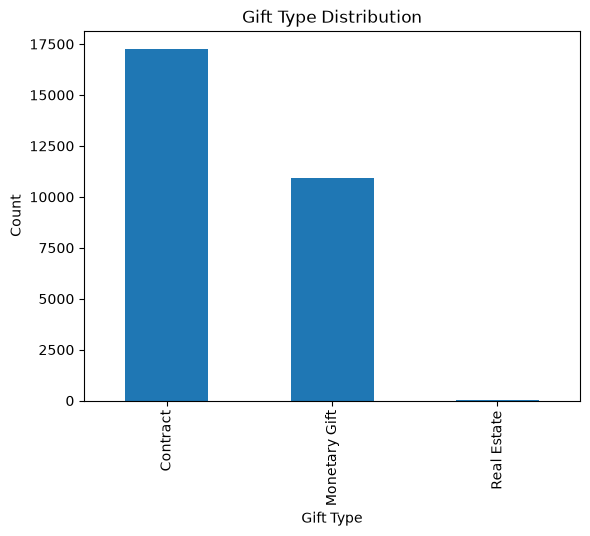

In [2]:
df['Gift Type'].value_counts().plot(kind='bar')
plt.title("Gift Type Distribution")
plt.ylabel("Count")

df['Gift Type'].value_counts() / len(df) 

There are 17274 gifts that are contracts, 10936 gifts that are monetary, and 11 gifts that are real estate. 0.612097 of the gifts are contracts, 0.387513 are monetary, and 0.000390 of the gifts are real estate. 

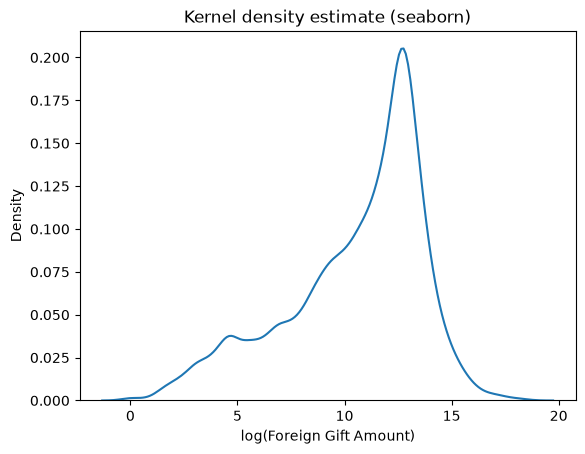

In [3]:
import seaborn as sns
x = df[df['Foreign Gift Amount'] > 0]
x_log = np.log(x['Foreign Gift Amount'])
ax = sns.kdeplot(x=x_log, bw_method="silverman")
ax.set(title="Kernel density estimate (seaborn)", xlabel="log(Foreign Gift Amount)", ylabel="Density")
plt.show()



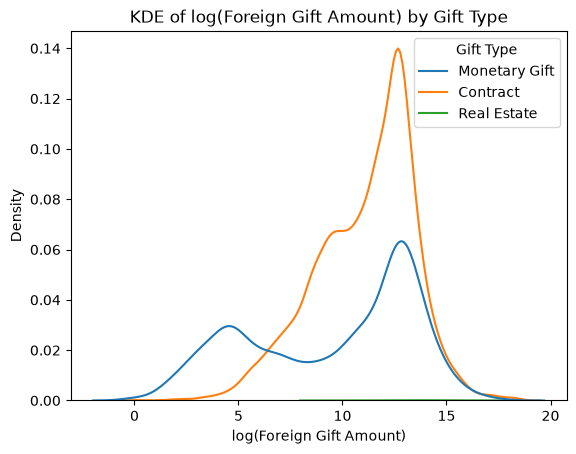

In [4]:

ax = sns.kdeplot(data=df, x=x_log, hue='Gift Type', bw_method="silverman")
ax.set(title="KDE of log(Foreign Gift Amount) by Gift Type",
       xlabel="log(Foreign Gift Amount)", ylabel="Density")
plt.show()

I notice that the Contract density plot is very similar to the KDE plot of the log of Foreign Gift Amount. This is most likely because most of the gifts were the Contract type. 

In [5]:
#found that Korea and South Korea are both listed, replace KOREA with SOUTH KOREA
df['Country of Giftor'].unique()
df['Country of Giftor'] = df['Country of Giftor'].replace({'KOREA': 'SOUTH KOREA'})
df.groupby('Country of Giftor').size().sort_values(ascending=False).head(15)


Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
SOUTH KOREA        1263
HONG KONG          1080
QATAR               693
THE NETHERLANDS     512
INDIA               434
TAIWAN              381
ISRAEL              373
dtype: int64

The top 15 countries are ENGLAND, CHINA, CANADA, JAPAN, SWITZERLAND, SAUDI ARABIA, FRANCE, GERMANY, SOUTH KOREA, HONG KONG, QATAR, THE NETHERLANDS, INDIA, TAIWAN, and ISRAEL. 

In [6]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
SOUTH KOREA              268654844
Name: Foreign Gift Amount, dtype: int64

The top 15 countries in terms of amount given is in the following order: QATAR, ENGLAND, CHINA. SAUDI ARABIA, BERMUDA, CANADA, HONG KONG, JAPAN, SWITZERLAND, INDIA, GERMANY, UNITED ARAB EMIRATES, FRANCE, SINGAPORE, and SOUTH KOREA

In [7]:
df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64

The top giftors that provide the most total amount of money are: 
Qatar Foundation                       (1166503744),
Qatar Foundation/Qatar National Res     (796197000),
Qatar Foundation for Education          (373945215),
Anonymous                               (338793629),
Saudi Arabian Cultural Mission          (275221475),
HCL                                     (190000000),
Church of Jesus Christ of LDS           (185203715),
Emirates Institute for Advanced Sc      (170641244),
QIC                                     (148355497),
Anonymous #9                             (96334996),
Qatar National Research Fund             (79021705),
Government of Saudi Arabia               (75192434),
Contracting Party                        (69996984),
CMKL University                          (67700000), and the 
Royal Embassy of Saudi Arabia            (67062486)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [8]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]